In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# from datasets import load_dataset
from nltk import word_tokenize          
from nltk.stem import WordNetLemmatizer 
import tiktoken

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier

from spacy.lang.fr.stop_words import STOP_WORDS as fr_stop
from spacy.lang.en.stop_words import STOP_WORDS as en_stop

In [2]:
df = pd.read_csv("MovieDataThread.csv")

In [3]:
df = df[df["imdb_id"].notna()]
df.drop(columns="imdb_id", inplace=True)
df.drop(columns=df.filter(like="tmdb_").columns, inplace=True)

In [4]:
df["genre_count"] = df.filter(regex='^imdb_(?!id$)').count(axis=1)

In [5]:
df = df[df["genre_count"] > 0]

In [ ]:
# df = df[(df["genre_count"] >= 1) & (df["genre_count"] <= 4)]
two_genres = df[df["genre_count"] == 2]
len(two_genres)

10682

In [6]:
genre_counts = two_genres.filter(like='imdb_').count().sort_values(ascending=False)
# Split genre_count into quartiles
genre_counts_quartiles = genre_counts.quantile([0.25, 0.5, 0.75])
# Select genres that are in the top quartile
top_genres = genre_counts[genre_counts >= genre_counts_quartiles[0.75]].index
top_genres = top_genres.sort_values(key=lambda x: genre_counts[x], ascending=False)
top_genres

NameError: name 'two_genres' is not defined

In [42]:
filtered_movies = two_genres[two_genres[top_genres].notna().sum(axis=1) == 2]
len(filtered_movies)

5897

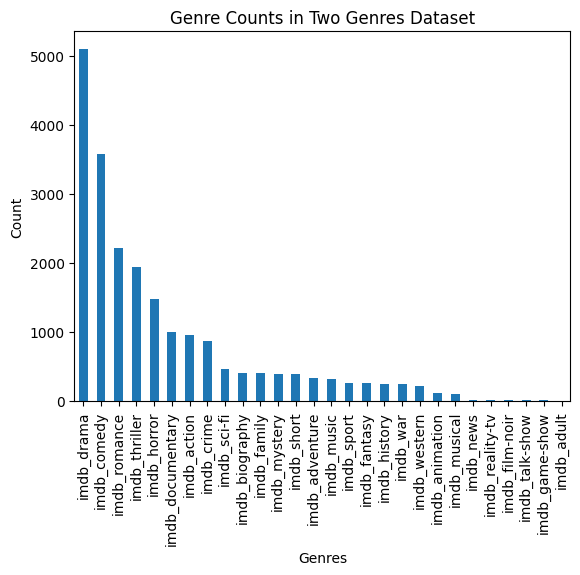

In [11]:
# Count the occurrences of each genre in the two_genres dataframe
genre_counts_two_genres = two_genres.filter(like='imdb_').count().sort_values(ascending=False)

# Plot the genre counts
genre_counts_two_genres.plot(kind='bar', title='Genre Counts in Two Genres Dataset')
plt.xlabel('Genres')
plt.ylabel('Count')
plt.show()

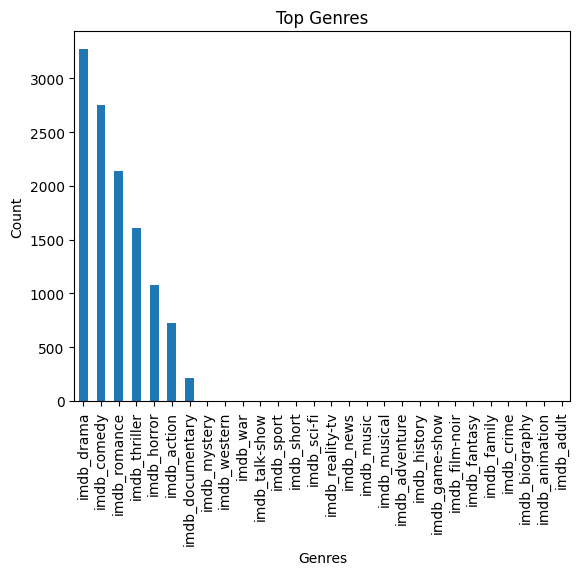

In [47]:
# Filter the genre counts for the top genres
top_genre_counts = filtered_movies.filter(like='imdb_').count().sort_values(ascending=False)

# Plot the top genres
top_genre_counts.plot(kind='bar', title='Top Genres')
plt.xlabel('Genres')
plt.ylabel('Count')
plt.show()

                          Genre Pair  Count
6           imdb_comedy & imdb_drama   3172
2          imdb_drama & imdb_romance   1459
8         imdb_comedy & imdb_romance   1008
36          imdb_action & imdb_drama    987
37         imdb_action & imdb_comedy    854
3           imdb_drama & imdb_horror    726
26       imdb_horror & imdb_thriller    639
1         imdb_drama & imdb_thriller    629
9          imdb_comedy & imdb_horror    485
38       imdb_action & imdb_thriller    331
40         imdb_action & imdb_horror    221
31    imdb_documentary & imdb_comedy    169
30     imdb_documentary & imdb_drama     90
7        imdb_comedy & imdb_thriller     49
35    imdb_documentary & imdb_action     32
39        imdb_action & imdb_romance     27
20      imdb_romance & imdb_thriller     21
34    imdb_documentary & imdb_horror     18
27        imdb_horror & imdb_romance     16
0           imdb_drama & imdb_comedy     14
18         imdb_romance & imdb_drama      6
32  imdb_documentary & imdb_thri

/var/folders/wj/yjxhfpzn5ssgymw3vblf52fh0000gn/T/ipykernel_28077/4212617320.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  genre_matrix = pd.DataFrame(index=genre_columns, columns=genre_columns).fillna(0)
/var/folders/wj/yjxhfpzn5ssgymw3vblf52fh0000gn/T/ipykernel_28077/4212617320.py:38: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combination_matrix = pd.DataFrame(index=genre_columns, columns=genre_columns).fillna(0)


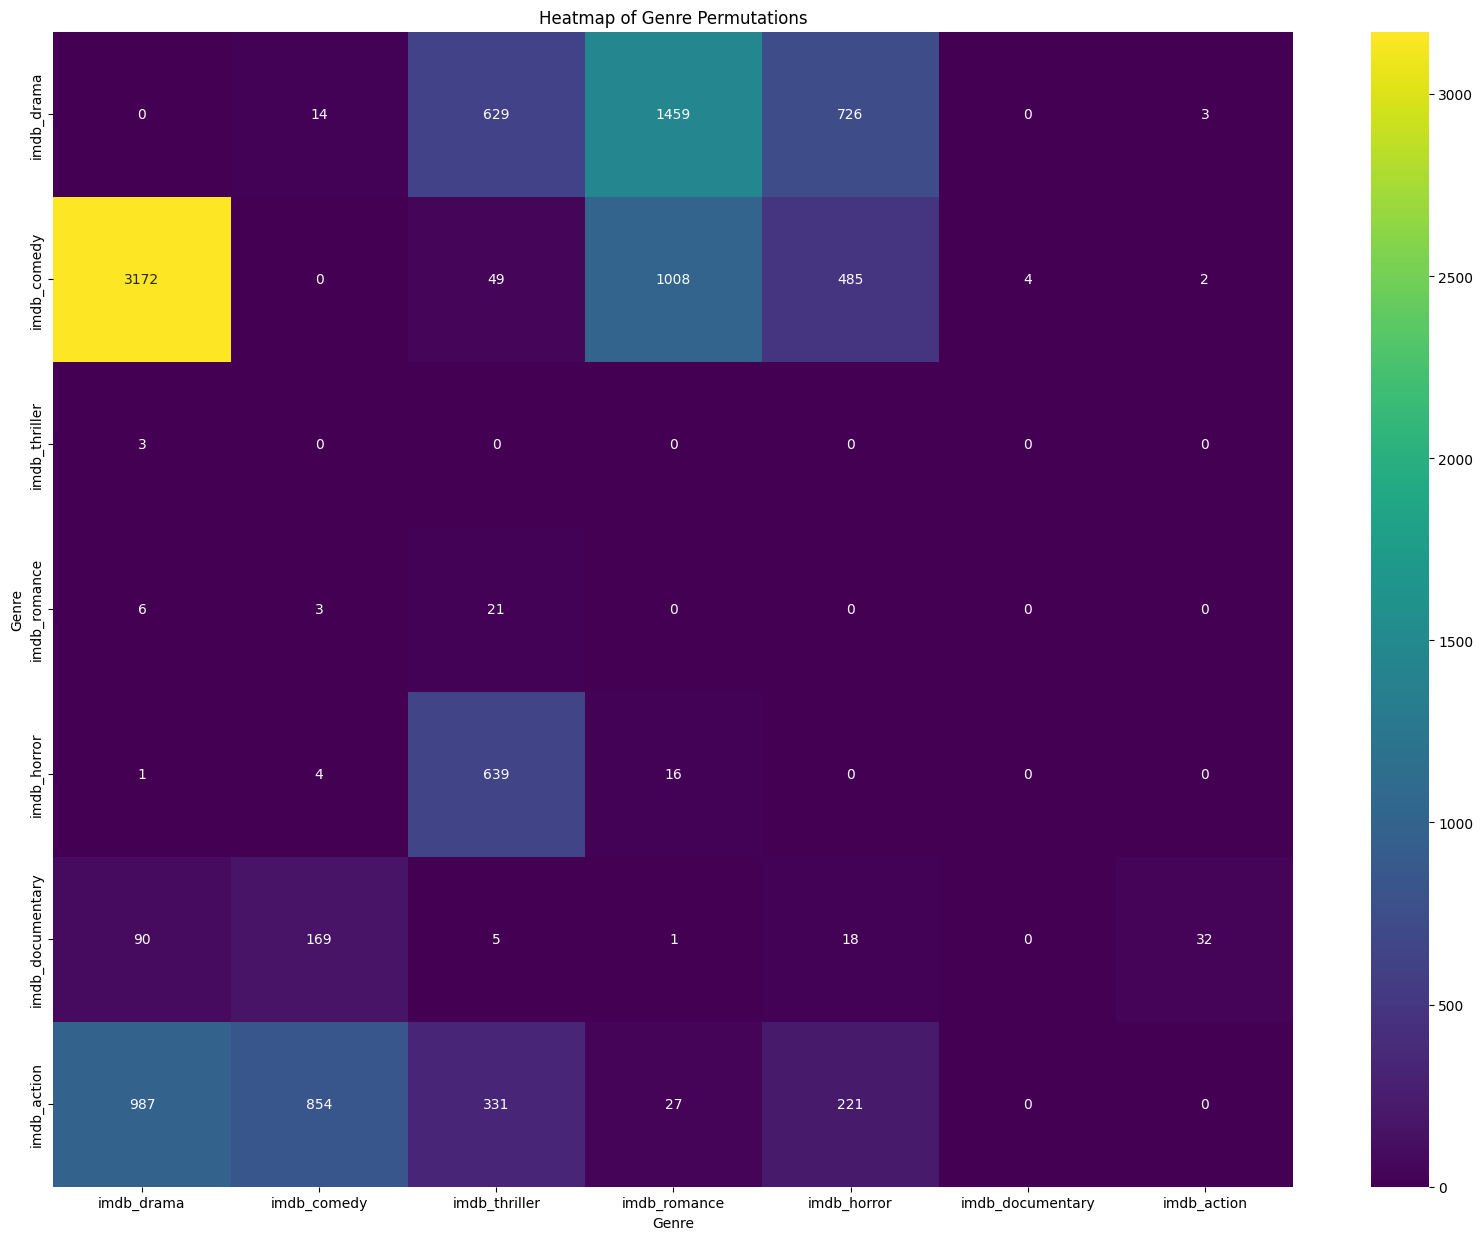

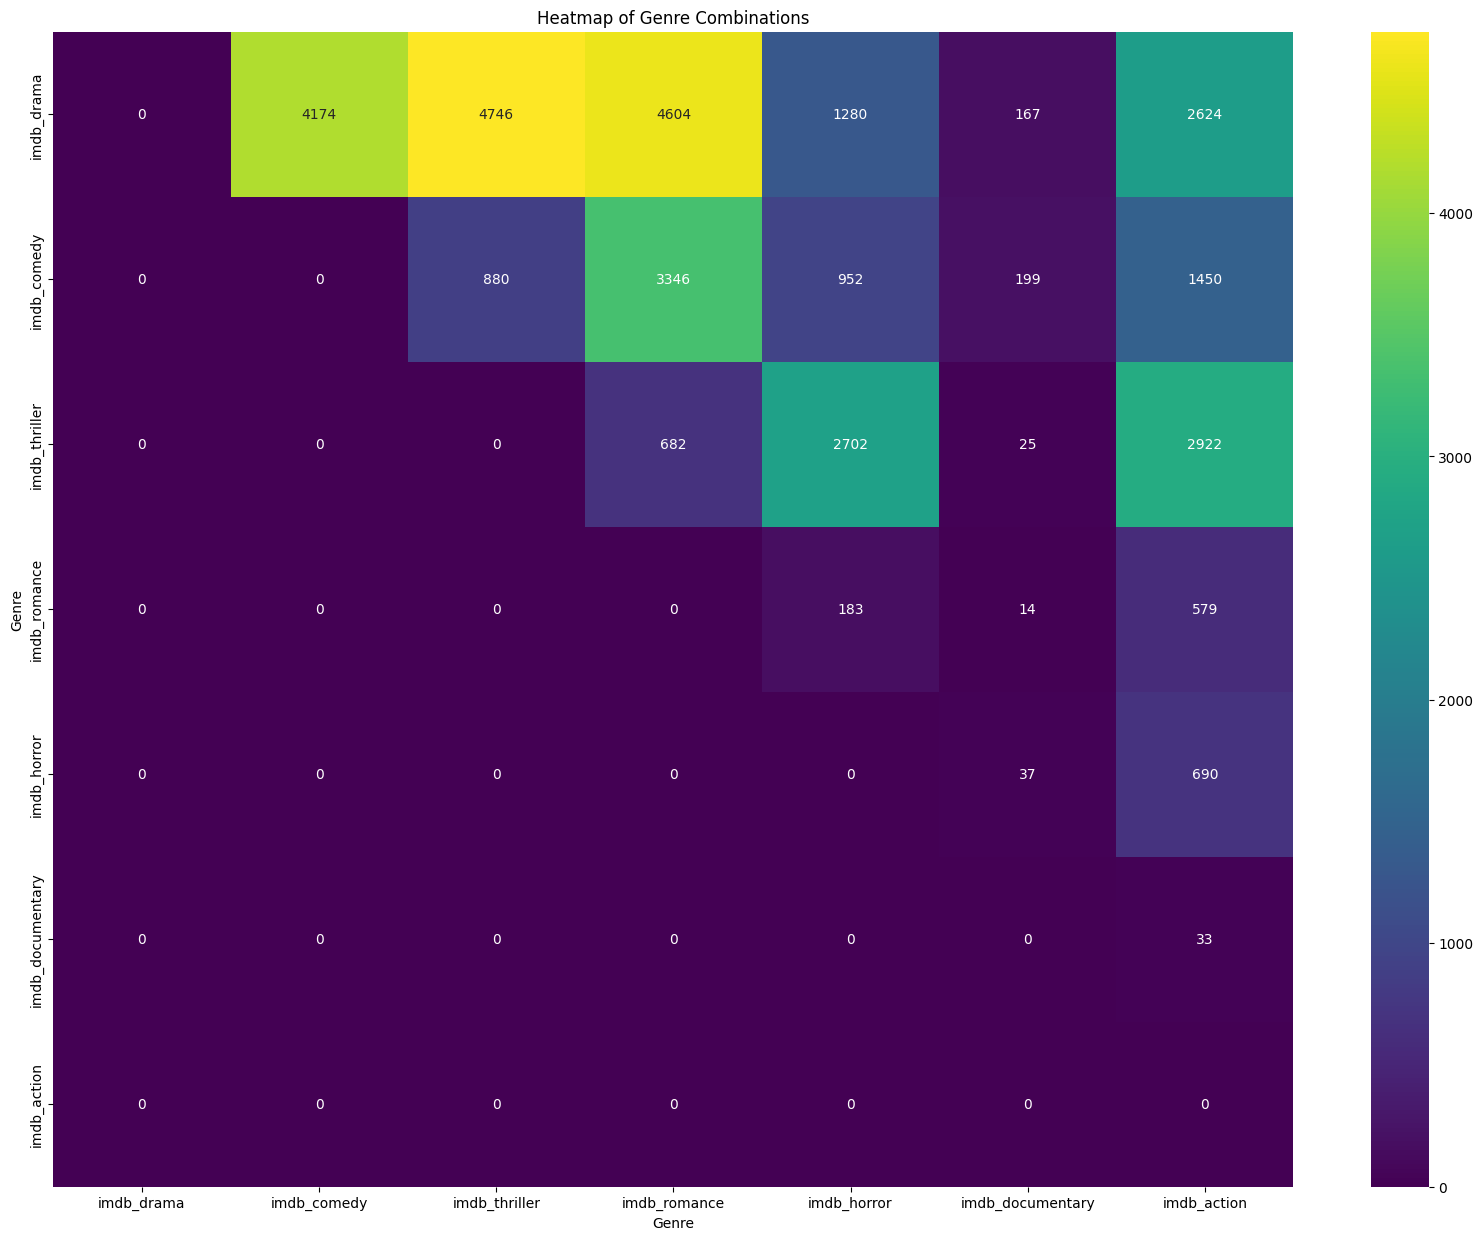

In [87]:
from itertools import combinations
from itertools import permutations

# Extract genre columns
# genre_columns = df.filter(like='imdb_').columns
genre_columns = two_genres[top_genres].filter(like='imdb_').columns

# Generate all pairs of genres
genre_pairs = list(permutations(genre_columns, 2))
genre_combinations = list(combinations(genre_columns, 2))

# Initialize a list to store counts for each pair
pair_counts = []
combination_counts = []

# Calculate counts for each pair and store them
for pair in genre_pairs:
    genre1, genre2 = pair
    # count = df[(df[genre1] >= 1) & (df[genre2] >= 1) & (df[genre1] < df[genre2])].shape[0]
    count = df[(df[genre1] == 1) & (df[genre2] == 2)].shape[0]
    pair_counts.append((f"{genre1} & {genre2}", count))

# Calculate counts for each combination and store them
for combination in genre_combinations:
    genre1, genre2 = combination
    # count = df[(df[genre1] >= 1) & (df[genre2] >= 1) & (df[genre1] < df[genre2])].shape[0]
    count = df[(df[genre1] >= 1) & (df[genre2] >= 1)].shape[0]
    combination_counts.append((f"{genre1} & {genre2}", count))

# Convert the list to a DataFrame for easier plotting
pair_counts_df = pd.DataFrame(pair_counts, columns=["Genre Pair", "Count"])
combination_counts_df = pd.DataFrame(combination_counts, columns=["Genre Combination", "Count"])

print(pair_counts_df.sort_values(by="Count", ascending=False))
genre_matrix = pd.DataFrame(index=genre_columns, columns=genre_columns).fillna(0)
print("combination")
print(combination_counts_df.sort_values(by="Count", ascending=False))
combination_matrix = pd.DataFrame(index=genre_columns, columns=genre_columns).fillna(0)

# Fill the matrix with counts
for pair, count in pair_counts:
    genre1, genre2 = pair.split(" & ")
    genre_matrix.at[genre1, genre2] = count
    # genre_matrix.at[genre2, genre1] = count

# Fill the combination matrix with counts
for combination, count in combination_counts:
    genre1, genre2 = combination.split(" & ")
    combination_matrix.at[genre1, genre2] = count
    # combination_matrix.at[genre2, genre1] = count

# Plot the heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(genre_matrix.astype(int), annot=True, fmt="d", cmap="viridis")
plt.xlabel('Genre')
plt.ylabel('Genre')
plt.title('Heatmap of Genre Permutations')
plt.show()

# Plot the heatmap for combinations
plt.figure(figsize=(20, 15))
sns.heatmap(combination_matrix.astype(int), annot=True, fmt="d", cmap="viridis")
plt.xlabel('Genre')
plt.ylabel('Genre')
plt.title('Heatmap of Genre Combinations')
plt.show()

## Suggestion
On peut peut etre créer des class hybrid avec uniqument les genres du premier quartile ou bien tous les genres

On pourrait aussi tester avec tous les films qui ont entre 1 et deux genre

Plutot qu'avec les permutations on pourrait essayer avec les combinaisons

Regarder évolution d'un genre au fil des années

Pour RNN on peut ou bien faire de la classification slide 8 petit b ou bien petit c concaténer le texte avec la classe et prédire la classe à la fin

# OneVsRestClassifier

## Avec deux genres

In [64]:
y = []

for _, row in filtered_movies.iterrows():
    genres = [col for col in filtered_movies.columns if col.startswith('imdb_') and not pd.isna(row[col])]
    y.append(genres)

In [50]:
y

[['imdb_drama', 'imdb_romance'],
 ['imdb_horror', 'imdb_thriller'],
 ['imdb_comedy', 'imdb_drama'],
 ['imdb_action', 'imdb_drama'],
 ['imdb_comedy', 'imdb_thriller'],
 ['imdb_drama', 'imdb_romance'],
 ['imdb_comedy', 'imdb_horror'],
 ['imdb_action', 'imdb_drama'],
 ['imdb_comedy', 'imdb_horror'],
 ['imdb_comedy', 'imdb_drama'],
 ['imdb_drama', 'imdb_romance'],
 ['imdb_comedy', 'imdb_drama'],
 ['imdb_comedy', 'imdb_drama'],
 ['imdb_action', 'imdb_thriller'],
 ['imdb_drama', 'imdb_thriller'],
 ['imdb_action', 'imdb_comedy'],
 ['imdb_drama', 'imdb_romance'],
 ['imdb_comedy', 'imdb_drama'],
 ['imdb_action', 'imdb_drama'],
 ['imdb_drama', 'imdb_romance'],
 ['imdb_comedy', 'imdb_documentary'],
 ['imdb_comedy', 'imdb_documentary'],
 ['imdb_comedy', 'imdb_documentary'],
 ['imdb_comedy', 'imdb_documentary'],
 ['imdb_action', 'imdb_thriller'],
 ['imdb_comedy', 'imdb_drama'],
 ['imdb_comedy', 'imdb_romance'],
 ['imdb_comedy', 'imdb_drama'],
 ['imdb_comedy', 'imdb_thriller'],
 ['imdb_comedy', 'imd

In [24]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

In [66]:
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(y) 

In [76]:
synopsis = filtered_movies["synopsis"].fillna("")
X = filtered_movies["Script"] + " " + synopsis 

In [79]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', OneVsRestClassifier(LinearSVC(max_iter=1000)))
])

# 4. Entraînement
pipeline.fit(X_train, y_train)

# 5. Évaluation
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

                  precision    recall  f1-score   support

     imdb_action       0.85      0.49      0.62       136
     imdb_comedy       0.80      0.76      0.78       561
imdb_documentary       0.94      0.76      0.84        45
      imdb_drama       0.71      0.85      0.77       612
     imdb_horror       0.88      0.61      0.72       235
    imdb_romance       0.81      0.74      0.77       425
   imdb_thriller       0.79      0.59      0.67       346

       micro avg       0.78      0.72      0.75      2360
       macro avg       0.83      0.69      0.74      2360
    weighted avg       0.79      0.72      0.75      2360
     samples avg       0.78      0.72      0.73      2360



/Users/aniss/Documents/clone/NLP/CM3/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [80]:
predicted_genres = mlb.inverse_transform(pipeline.predict(["War and Peace"]))
predicted_genres

[('imdb_drama',)]

### Interpretation
Bien meilleur sur romance que le modèle avec une seule class

## Tous les films

In [19]:
y = []

for _, row in df.iterrows():
    genres = [col for col in df.columns if col.startswith('imdb_') and not pd.isna(row[col])]
    y.append(genres)

In [20]:
y

[['imdb_horror'],
 ['imdb_documentary', 'imdb_drama', 'imdb_history'],
 ['imdb_drama', 'imdb_film-noir', 'imdb_romance', 'imdb_thriller'],
 ['imdb_drama'],
 ['imdb_horror', 'imdb_short'],
 ['imdb_drama'],
 ['imdb_biography', 'imdb_documentary', 'imdb_romance', 'imdb_sci-fi'],
 ['imdb_drama', 'imdb_music', 'imdb_romance'],
 ['imdb_action', 'imdb_adventure', 'imdb_drama', 'imdb_romance'],
 ['imdb_crime', 'imdb_mystery', 'imdb_thriller'],
 ['imdb_drama', 'imdb_mystery', 'imdb_thriller'],
 ['imdb_action', 'imdb_adventure'],
 ['imdb_action', 'imdb_adventure', 'imdb_thriller'],
 ['imdb_drama', 'imdb_romance'],
 ['imdb_biography', 'imdb_drama', 'imdb_music', 'imdb_musical'],
 ['imdb_comedy', 'imdb_drama', 'imdb_music'],
 ['imdb_drama', 'imdb_horror', 'imdb_mystery'],
 ['imdb_biography', 'imdb_drama', 'imdb_history'],
 ['imdb_biography', 'imdb_drama', 'imdb_sport'],
 ['imdb_comedy', 'imdb_crime'],
 ['imdb_horror', 'imdb_thriller'],
 ['imdb_comedy', 'imdb_drama'],
 ['imdb_drama'],
 ['imdb_actio

In [21]:
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(y)
synopsis = df["synopsis"].fillna("")
X = df["Script"] + " " + synopsis 

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', OneVsRestClassifier(LinearSVC(max_iter=1000)))
])

# 4. Entraînement
pipeline.fit(X_train, y_train)

# 5. Évaluation
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

## Films tous les genres dans le premier quartile

In [14]:
# count genres
genre_counts = df.filter(like='imdb_').count().sort_values(ascending=False)
# first quartile of genre counts
genre_counts_quartiles = genre_counts.quantile([0.25, 0.5, 0.75])
# Select genres that are in the top quartile
top_genres = genre_counts[genre_counts >= genre_counts_quartiles[0.75]].index
top_genres = top_genres.sort_values(key=lambda x: genre_counts[x], ascending=False)
# Filter the movies to include only thoses with all genres in the top quartile
filtered_movies = df[df[top_genres].notna().sum(axis=1) == df["genre_count"]]

In [15]:
y = []

for _, row in filtered_movies.iterrows():
    genres = [col for col in filtered_movies.columns if col.startswith('imdb_') and not pd.isna(row[col])]
    y.append(genres)

In [16]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(y)
synopsis = filtered_movies["synopsis"].fillna("")
X = filtered_movies["Script"] + " " + synopsis 

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', OneVsRestClassifier(LinearSVC(max_iter=1000)))
])

# 4. Entraînement
pipeline.fit(X_train, y_train)

# 5. Évaluation
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

               precision    recall  f1-score   support

  imdb_action       0.84      0.56      0.67       550
  imdb_comedy       0.78      0.68      0.73      1310
   imdb_crime       0.75      0.42      0.54       593
   imdb_drama       0.75      0.83      0.79      1975
  imdb_horror       0.88      0.64      0.74       527
 imdb_romance       0.70      0.49      0.58       794
imdb_thriller       0.69      0.52      0.59       949

    micro avg       0.76      0.64      0.70      6698
    macro avg       0.77      0.59      0.66      6698
 weighted avg       0.76      0.64      0.69      6698
  samples avg       0.76      0.69      0.68      6698



/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
# Calculer la precision
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.34


In [91]:
# predict genres for a new movie
script = ""
predicted_genres = mlb.inverse_transform(pipeline.predict([script]))
predicted_genres

[('imdb_drama',)]

Avec Doc2Vec

In [17]:
synopsis = filtered_movies["synopsis"].fillna("")
X = filtered_movies["Script"] + " " + synopsis
tokens_synopsis = X.apply(lambda x: [word for word in word_tokenize(x.lower()) if word.isalpha() and word not in en_stop])

from gensim.models.doc2vec import TaggedDocument, Doc2Vec

# Convert tokens_synopsis to a list of TaggedDocument objects
tagged_documents = [TaggedDocument(words=doc, tags=[i]) for i, doc in enumerate(tokens_synopsis)]

doc_vec = Doc2Vec(
    documents=tagged_documents,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=20
)


In [26]:

# Generate embeddings for the dataset using the trained Doc2Vec model
X_embeddings = [doc_vec.infer_vector(doc.words) for doc in tagged_documents]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_embeddings, y, test_size=0.2, random_state=42)

# Define the OneVsRestClassifier with LinearSVC
pipeline = Pipeline([
    ('clf', OneVsRestClassifier(LinearSVC(max_iter=1000)))
])

# Train the classifier
pipeline.fit(X_train, y_train)

# Evaluate the classifier
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

               precision    recall  f1-score   support

  imdb_action       0.78      0.66      0.71       546
  imdb_comedy       0.79      0.70      0.74      1318
   imdb_crime       0.70      0.47      0.57       641
   imdb_drama       0.76      0.81      0.78      1981
  imdb_horror       0.84      0.69      0.76       523
 imdb_romance       0.71      0.50      0.59       811
imdb_thriller       0.69      0.51      0.59       969

    micro avg       0.75      0.66      0.70      6789
    macro avg       0.75      0.62      0.68      6789
 weighted avg       0.75      0.66      0.70      6789
  samples avg       0.76      0.71      0.69      6789



/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
# Calculer la precision
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.30


## Tous les films du premier quartile sans drama

In [7]:
# count genres
genre_counts = df.drop(columns="imdb_drama").filter(like='imdb_').count().sort_values(ascending=False)
# first quartile of genre counts
genre_counts_quartiles = genre_counts.quantile([0.25, 0.5, 0.75])
# Select genres that are in the top quartile
top_genres = genre_counts[genre_counts >= genre_counts_quartiles[0.75]].index
top_genres = top_genres.sort_values(key=lambda x: genre_counts[x], ascending=False)
# Filter the movies to include only thoses with all genres in the top quartile
filtered_movies = df[df[top_genres].notna().sum(axis=1) == df["genre_count"]]

In [10]:
y = []

for _, row in filtered_movies.iterrows():
    genres = [col for col in filtered_movies.columns if col.startswith('imdb_') and not pd.isna(row[col])]
    y.append(genres)
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(y)
synopsis = filtered_movies["synopsis"].fillna("")
X = filtered_movies["Script"] + " " + synopsis 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# 3. Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', OneVsRestClassifier(LinearSVC(max_iter=1000)))
])

# 4. Entraînement
pipeline.fit(X_train, y_train)

# 5. Évaluation
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

                precision    recall  f1-score   support

   imdb_action       0.83      0.62      0.71       375
imdb_adventure       1.00      0.06      0.11        88
   imdb_comedy       0.83      0.83      0.83       778
    imdb_crime       0.78      0.29      0.42       251
   imdb_horror       0.90      0.74      0.81       456
  imdb_romance       0.83      0.56      0.67       298
 imdb_thriller       0.70      0.57      0.63       539

     micro avg       0.81      0.64      0.71      2785
     macro avg       0.84      0.52      0.60      2785
  weighted avg       0.82      0.64      0.69      2785
   samples avg       0.77      0.69      0.69      2785



/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Film avec un ou deux genres

In [10]:
one_or_two_genres = df[df["genre_count"] <= 2]
len(one_or_two_genres)

19973

In [11]:
genre_counts = one_or_two_genres.filter(like='imdb_').count().sort_values(ascending=False)
# Split genre_count into quartiles
genre_counts_quartiles = genre_counts.quantile([0.25, 0.5, 0.75])
# Select genres that are in the top quartile
top_genres = genre_counts[genre_counts >= genre_counts_quartiles[0.75]].index
top_genres = top_genres.sort_values(key=lambda x: genre_counts[x], ascending=False)
top_genres

Index(['imdb_drama', 'imdb_comedy', 'imdb_thriller', 'imdb_romance',
       'imdb_horror', 'imdb_documentary', 'imdb_action'],
      dtype='object')

In [15]:
filtered_movies = one_or_two_genres[one_or_two_genres[top_genres].notna().sum(axis=1) == one_or_two_genres["genre_count"]]
len(filtered_movies)

14397

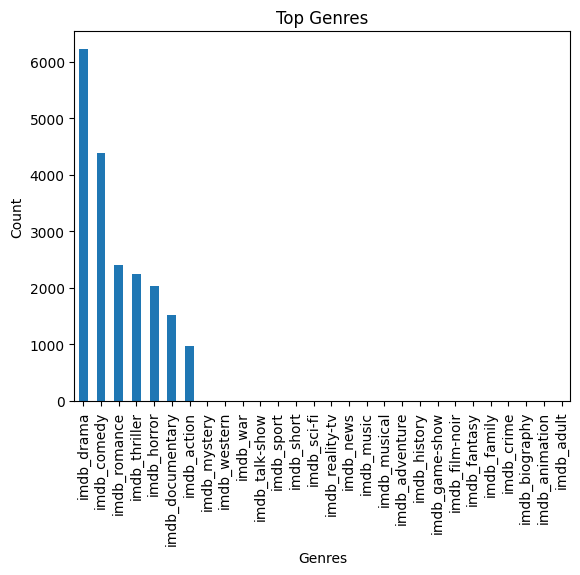

In [22]:
# Filter the genre counts for the top genres
top_genre_counts = filtered_movies.filter(like='imdb_').count().sort_values(ascending=False)

# Plot the top genres
top_genre_counts.plot(kind='bar', title='Top Genres')
plt.xlabel('Genres')
plt.ylabel('Count')
plt.show()

In [23]:
y = []
for _, row in filtered_movies.iterrows():
    genres = [col for col in filtered_movies.columns if col.startswith('imdb_') and not pd.isna(row[col])]
    y.append(genres)

In [24]:
y

[['imdb_horror'],
 ['imdb_drama'],
 ['imdb_drama'],
 ['imdb_drama', 'imdb_romance'],
 [],
 ['imdb_horror', 'imdb_thriller'],
 ['imdb_comedy', 'imdb_drama'],
 ['imdb_drama'],
 ['imdb_drama'],
 ['imdb_action', 'imdb_drama'],
 ['imdb_drama'],
 ['imdb_comedy', 'imdb_thriller'],
 ['imdb_drama', 'imdb_romance'],
 ['imdb_comedy'],
 ['imdb_action'],
 ['imdb_comedy', 'imdb_horror'],
 ['imdb_action'],
 ['imdb_action', 'imdb_drama'],
 ['imdb_drama'],
 ['imdb_comedy', 'imdb_horror'],
 ['imdb_thriller'],
 ['imdb_drama'],
 ['imdb_drama'],
 ['imdb_drama'],
 ['imdb_comedy'],
 ['imdb_documentary'],
 ['imdb_comedy'],
 ['imdb_comedy', 'imdb_drama'],
 ['imdb_drama', 'imdb_romance'],
 ['imdb_comedy', 'imdb_drama'],
 ['imdb_horror'],
 ['imdb_comedy', 'imdb_drama'],
 ['imdb_thriller'],
 ['imdb_romance'],
 ['imdb_action', 'imdb_thriller'],
 ['imdb_documentary'],
 ['imdb_documentary'],
 ['imdb_drama', 'imdb_thriller'],
 [],
 ['imdb_action', 'imdb_comedy'],
 ['imdb_drama', 'imdb_romance'],
 ['imdb_comedy', 'imd

In [ ]:
synopsis = filtered_movies["synopsis"].fillna("")
X = filtered_movies["Script"] + " " + synopsis 
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(y)

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', OneVsRestClassifier(LinearSVC(max_iter=1000)))
])

# 4. Entraînement
pipeline.fit(X_train, y_train)

# 5. Évaluation
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

                  precision    recall  f1-score   support

     imdb_action       0.88      0.32      0.47       201
     imdb_comedy       0.78      0.60      0.68       884
imdb_documentary       0.91      0.81      0.85       276
      imdb_drama       0.74      0.72      0.73      1272
     imdb_horror       0.82      0.62      0.70       400
    imdb_romance       0.71      0.36      0.47       499
   imdb_thriller       0.62      0.31      0.41       463

       micro avg       0.76      0.58      0.66      3995
       macro avg       0.78      0.53      0.62      3995
    weighted avg       0.76      0.58      0.64      3995
     samples avg       0.67      0.60      0.61      3995



/Users/aniss/Documents/clone/NLP/CM3/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/aniss/Documents/clone/NLP/CM3/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/aniss/Documents/clone/NLP/CM3/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

# Hybrid class
Film avec deux genres en faire une class hybrid. D'abord en considérant les permutations puis les combinaisons.

In [ ]:
y = []
for _, row in filtered_movies.iterrows():
    genres = [col for col in filtered_movies.columns if col.startswith('imdb_') and not pd.isna(row[col])]
    y.append(genres)

In [108]:
y

[['imdb_horror'],
 ['imdb_drama'],
 ['imdb_drama'],
 ['imdb_drama', 'imdb_romance'],
 [],
 ['imdb_horror', 'imdb_thriller'],
 ['imdb_comedy', 'imdb_drama'],
 ['imdb_drama'],
 ['imdb_drama'],
 ['imdb_action', 'imdb_drama'],
 ['imdb_drama'],
 ['imdb_comedy', 'imdb_thriller'],
 ['imdb_drama', 'imdb_romance'],
 ['imdb_comedy'],
 ['imdb_action'],
 ['imdb_comedy', 'imdb_horror'],
 ['imdb_action'],
 ['imdb_action', 'imdb_drama'],
 ['imdb_drama'],
 ['imdb_comedy', 'imdb_horror'],
 ['imdb_thriller'],
 ['imdb_drama'],
 ['imdb_drama'],
 ['imdb_drama'],
 ['imdb_comedy'],
 ['imdb_documentary'],
 ['imdb_comedy'],
 ['imdb_comedy', 'imdb_drama'],
 ['imdb_drama', 'imdb_romance'],
 ['imdb_comedy', 'imdb_drama'],
 ['imdb_horror'],
 ['imdb_comedy', 'imdb_drama'],
 ['imdb_thriller'],
 ['imdb_romance'],
 ['imdb_action', 'imdb_thriller'],
 ['imdb_documentary'],
 ['imdb_documentary'],
 ['imdb_drama', 'imdb_thriller'],
 [],
 ['imdb_action', 'imdb_comedy'],
 ['imdb_drama', 'imdb_romance'],
 ['imdb_comedy', 'imd

In [109]:
def create_hybrid_labels(labels, top_pairs, min_count=0):
    new_labels = []
    if len(labels) < 2:
        return labels
    for movie_labels in labels:
        # Conserver les labels originaux
        enhanced_labels = set(movie_labels)
        
        # Ajouter les paires présentes
        for pair in top_pairs:
            genre = pair[0]
            count = pair[1]
            g1, g2 = genre.split(' & ')
            if g1 in movie_labels and g2 in movie_labels and count >= min_count:
                enhanced_labels = [genre]
                break
                
        new_labels.append(list(enhanced_labels))
    
    return new_labels

enhanced_labels = create_hybrid_labels(y, combination_counts, 2000)

In [110]:
enhanced_labels

[['imdb_horror'],
 ['imdb_drama'],
 ['imdb_drama'],
 ['imdb_drama & imdb_romance'],
 [],
 ['imdb_thriller & imdb_horror'],
 ['imdb_drama & imdb_comedy'],
 ['imdb_drama'],
 ['imdb_drama'],
 ['imdb_drama & imdb_action'],
 ['imdb_drama'],
 ['imdb_thriller', 'imdb_comedy'],
 ['imdb_drama & imdb_romance'],
 ['imdb_comedy'],
 ['imdb_action'],
 ['imdb_horror', 'imdb_comedy'],
 ['imdb_action'],
 ['imdb_drama & imdb_action'],
 ['imdb_drama'],
 ['imdb_horror', 'imdb_comedy'],
 ['imdb_thriller'],
 ['imdb_drama'],
 ['imdb_drama'],
 ['imdb_drama'],
 ['imdb_comedy'],
 ['imdb_documentary'],
 ['imdb_comedy'],
 ['imdb_drama & imdb_comedy'],
 ['imdb_drama & imdb_romance'],
 ['imdb_drama & imdb_comedy'],
 ['imdb_horror'],
 ['imdb_drama & imdb_comedy'],
 ['imdb_thriller'],
 ['imdb_romance'],
 ['imdb_thriller & imdb_action'],
 ['imdb_documentary'],
 ['imdb_documentary'],
 ['imdb_drama & imdb_thriller'],
 [],
 ['imdb_action', 'imdb_comedy'],
 ['imdb_drama & imdb_romance'],
 ['imdb_drama & imdb_comedy'],
 []

In [ ]:
horror_comedy_movies = df[(df["imdb_horror"].notna()) & (df["imdb_comedy"].notna())]
print(horror_comedy_movies[["Title", "imdb_horror", "imdb_comedy"]])

In [111]:
synopsis = filtered_movies["synopsis"].fillna("")
X = filtered_movies["Script"] + " " + synopsis
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(enhanced_labels)  

In [112]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', OneVsRestClassifier(LinearSVC(max_iter=1000)))
])

# 4. Entraînement
pipeline.fit(X_train, y_train)

# 5. Évaluation
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

                             precision    recall  f1-score   support

                imdb_action       0.75      0.03      0.05       108
                imdb_comedy       0.79      0.37      0.50       452
 imdb_comedy & imdb_romance       0.75      0.06      0.11       202
           imdb_documentary       0.89      0.77      0.83       299
                 imdb_drama       0.58      0.27      0.37       612
   imdb_drama & imdb_action       0.00      0.00      0.00        35
   imdb_drama & imdb_comedy       0.80      0.03      0.06       253
  imdb_drama & imdb_romance       0.48      0.06      0.11       218
 imdb_drama & imdb_thriller       1.00      0.01      0.02       113
                imdb_horror       0.71      0.33      0.45       280
               imdb_romance       0.00      0.00      0.00        57
              imdb_thriller       0.56      0.04      0.07       135
imdb_thriller & imdb_action       0.88      0.12      0.21        58
imdb_thriller & imdb_horror      

/Users/aniss/Documents/clone/NLP/CM3/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/aniss/Documents/clone/NLP/CM3/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/aniss/Documents/clone/NLP/CM3/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{met

Résultat mauvais, très gros surapprentissage

# Bag of words

In [17]:
# count genres
genre_counts = df.filter(like='imdb_').count().sort_values(ascending=False)
# first quartile of genre counts
genre_counts_quartiles = genre_counts.quantile([0.25, 0.5, 0.75])
# Select genres that are in the top quartile
top_genres = genre_counts[genre_counts >= genre_counts_quartiles[0.75]].index
top_genres = top_genres.sort_values(key=lambda x: genre_counts[x], ascending=False)
# Filter the movies to include only thoses with all genres in the top quartile
filtered_movies = df[df[top_genres].notna().sum(axis=1) == df["genre_count"]]

In [8]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import MultiLabelBinarizer
import spacy  # Pour le tokenizer personnalisé (optionnel)

# 1. Chargement des données et préparation des étiquettes
synopsis = filtered_movies["synopsis"].fillna("")
X = filtered_movies["Script"] + " " + synopsis  # Fusion des textes

# Extraction des étiquettes multi-labels (colonnes 'imdb_*')
y = []
for _, row in filtered_movies.iterrows():
    genres = [col for col in filtered_movies.columns if col.startswith('imdb_') and not pd.isna(row[col])]
    y.append(genres)

# Transformation des étiquettes en format binaire
mlb = MultiLabelBinarizer()
y_binarized = mlb.fit_transform(y)

# 3. Vectorisation Bag of Words
vectorizer = CountVectorizer(
    tokenizer=word_tokenize,  # Remplacer par None pour utiliser le tokenizer par défaut
    max_features=5000,          # Limiter le nombre de features
    ngram_range=(1, 2)          # Unigrammes + bigrammes
)
X_bow = vectorizer.fit_transform(X)

# 4. Séparation des données
X_train, X_test, y_train, y_test = train_test_split(X_bow, y_binarized, test_size=0.2, random_state=42)

# 5. Modèle Bayésien naïf multi-label
model = MultiOutputClassifier(MultinomialNB(alpha=0.1))  # alpha = lissage de Laplace
model.fit(X_train, y_train)

# 6. Prédiction et évaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=mlb.classes_, zero_division=0))

/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


               precision    recall  f1-score   support

  imdb_action       0.35      0.70      0.47       546
  imdb_comedy       0.58      0.68      0.63      1318
   imdb_crime       0.36      0.78      0.49       641
   imdb_drama       0.70      0.72      0.71      1981
  imdb_horror       0.36      0.61      0.45       523
 imdb_romance       0.41      0.76      0.53       811
imdb_thriller       0.48      0.66      0.56       969

    micro avg       0.49      0.70      0.58      6789
    macro avg       0.46      0.70      0.55      6789
 weighted avg       0.52      0.70      0.59      6789
  samples avg       0.50      0.71      0.55      6789



In [12]:
from sklearn.metrics import accuracy_score
# Calculer l'accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy multilabel (exact match): {accuracy:.2f}")

Accuracy multilabel (exact match): 0.11


In [33]:
# prediction pour un nouveau film
new_script = "comedy horror"
new_X = [new_script]
new_X_bow = vectorizer.transform(new_X)
predicted_labels = model.predict(new_X_bow)
predicted_genres = mlb.inverse_transform(predicted_labels)
predicted_genres

[('imdb_drama',)]

In [20]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import MultiLabelBinarizer
import spacy  # Pour le tokenizer personnalisé (optionnel)

# 1. Chargement des données et préparation des étiquettes
synopsis = filtered_movies["synopsis"].fillna("")
X = filtered_movies["Script"] + " " + synopsis  # Fusion des textes

# Extraction des étiquettes multi-labels (colonnes 'imdb_*')
y = []
for _, row in filtered_movies.iterrows():
    genres = [col for col in filtered_movies.columns if col.startswith('imdb_') and not pd.isna(row[col])]
    y.append(genres)

# Transformation des étiquettes en format binaire
mlb = MultiLabelBinarizer()
y_binarized = mlb.fit_transform(y)

# 3. Vectorisation Bag of Words
vectorizer = CountVectorizer(
    tokenizer=word_tokenize,  # Remplacer par None pour utiliser le tokenizer par défaut
    max_features=5000,          # Limiter le nombre de features
    ngram_range=(1, 1)          # Unigrammes only
)
X_bow = vectorizer.fit_transform(X)

# 4. Séparation des données
X_train, X_test, y_train, y_test = train_test_split(X_bow, y_binarized, test_size=0.2, random_state=42)

# 5. Modèle Bayésien naïf multi-label
model = MultiOutputClassifier(MultinomialNB(alpha=0.1))  # alpha = lissage de Laplace
model.fit(X_train, y_train)

# 6. Prédiction et évaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=mlb.classes_, zero_division=0))

/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


               precision    recall  f1-score   support

  imdb_action       0.41      0.73      0.52       546
  imdb_comedy       0.58      0.72      0.64      1318
   imdb_crime       0.41      0.77      0.53       641
   imdb_drama       0.70      0.73      0.71      1981
  imdb_horror       0.40      0.62      0.48       523
 imdb_romance       0.42      0.77      0.55       811
imdb_thriller       0.52      0.66      0.58       969

    micro avg       0.52      0.72      0.60      6789
    macro avg       0.49      0.71      0.57      6789
 weighted avg       0.54      0.72      0.61      6789
  samples avg       0.52      0.73      0.57      6789



In [21]:
# Calculer l'accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy multilabel (exact match): {accuracy:.2f}")

Accuracy multilabel (exact match): 0.12


# Baysien naif multi label

## Premier quartile

In [14]:
from sklearn.pipeline import make_pipeline


In [13]:
# count genres
genre_counts = df.filter(like='imdb_').count().sort_values(ascending=False)
# first quartile of genre counts
genre_counts_quartiles = genre_counts.quantile([0.25, 0.5, 0.75])
# Select genres that are in the top quartile
top_genres = genre_counts[genre_counts >= genre_counts_quartiles[0.75]].index
top_genres = top_genres.sort_values(key=lambda x: genre_counts[x], ascending=False)
# Filter the movies to include only thoses with all genres in the top quartile
filtered_movies = df[df[top_genres].notna().sum(axis=1) == df["genre_count"]]

In [14]:
import pandas as pd
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import MultiLabelBinarizer

# Supposons que filtered_movies est déjà chargé
synopsis = filtered_movies["synopsis"].fillna("")
X = filtered_movies["Script"] + " " + synopsis  # Concaténation du script et du synopsis

# Extraction des étiquettes multi-labels (colonnes commençant par 'imdb_')
y = []
for _, row in filtered_movies.iterrows():
    genres = [col for col in filtered_movies.columns if col.startswith('imdb_') and not pd.isna(row[col])]
    y.append(genres)

# Transformation des étiquettes en format binaire (matrice 0/1)
mlb = MultiLabelBinarizer()
y_binarized = mlb.fit_transform(y)

# Vectorisation du texte avec TF-IDF (meilleur que CountVectorizer pour Naive Bayes)
vectorizer = TfidfVectorizer(tokenizer=word_tokenize, max_features=5000, stop_words="english")
X_vectorized = vectorizer.fit_transform(X)

# Séparation train-test
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y_binarized, test_size=0.2, random_state=42)

# Initialisation du modèle Naive Bayes multi-label
# On utilise MultiOutputClassifier pour entraîner un classifieur par étiquette
model = MultiOutputClassifier(MultinomialNB(alpha=0.1))  # alpha = lissage Laplace
model.fit(X_train, y_train)

# Prédiction et évaluation
y_pred = model.predict(X_test)

# Affichage des résultats
print(classification_report(y_test, y_pred, target_names=mlb.classes_, zero_division=0))

/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


               precision    recall  f1-score   support

  imdb_action       0.80      0.06      0.12       546
  imdb_comedy       0.91      0.05      0.09      1318
   imdb_crime       0.67      0.00      0.01       641
   imdb_drama       0.62      0.89      0.73      1981
  imdb_horror       0.78      0.08      0.15       523
 imdb_romance       0.71      0.01      0.01       811
imdb_thriller       0.74      0.02      0.04       969

    micro avg       0.63      0.28      0.39      6789
    macro avg       0.75      0.16      0.16      6789
 weighted avg       0.74      0.28      0.26      6789
  samples avg       0.53      0.33      0.38      6789



In [30]:
# prediction pour un nouveau film
script = "funny laughing comedy"
predicted_genres = mlb.inverse_transform(model.predict(vectorizer.transform([script])))
predicted_genres

[('imdb_comedy',)]

In [15]:
# Calculer l'accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy multilabel (exact match): {accuracy:.2f}")

Accuracy multilabel (exact match): 0.16


# Feedforward

## TFIDF

### Avec drama

In [7]:
# count genres
genre_counts = df.filter(like='imdb_').count().sort_values(ascending=False)
# first quartile of genre counts
genre_counts_quartiles = genre_counts.quantile([0.25, 0.5, 0.75])
# Select genres that are in the top quartile
top_genres = genre_counts[genre_counts >= genre_counts_quartiles[0.75]].index
top_genres = top_genres.sort_values(key=lambda x: genre_counts[x], ascending=False)
# Filter the movies to include only thoses with all genres in the top quartile
filtered_movies = df[df[top_genres].notna().sum(axis=1) == df["genre_count"]]

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [9]:
from sklearn.preprocessing import MultiLabelBinarizer
y = []

for _, row in filtered_movies.iterrows():
    genres = [col for col in filtered_movies.columns if col.startswith('imdb_') and not pd.isna(row[col])]
    y.append(genres)
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(y)
synopsis = filtered_movies["synopsis"].fillna("")
X = filtered_movies["Script"] + " " + synopsis
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [11]:


# Convert X_train to numerical format using TfidfVectorizer
vectorizer = TfidfVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train).toarray()
X_test_vectorized = vectorizer.transform(X_test).toarray()

# Define the model
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train_vectorized.shape[1]))
model.add(Dense(y_train.shape[1], activation='sigmoid'))  # Une sortie par étiquette
model.compile(loss='binary_crossentropy', optimizer='adam')

# Train the model
model.fit(X_train_vectorized, y_train, epochs=100, callbacks=[EarlyStopping(patience=10)])


/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - loss: 0.5441
Epoch 2/100
  2/438 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - loss: 0.4369 

/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


438/438 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - loss: 0.3928
Epoch 3/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - loss: 0.3021
Epoch 4/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - loss: 0.2284
Epoch 5/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - loss: 0.1689
Epoch 6/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - loss: 0.1213
Epoch 7/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - loss: 0.0841
Epoch 8/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - loss: 0.0598
Epoch 9/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - loss: 0.0416
Epoch 10/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - loss: 0.0288
Epoch 11/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - loss: 0.0205
Epoch 12/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - loss: 0.0150
Epoch 13/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 25s 57ms/step - loss: 0.0110
Epoch 14/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - loss: 0.0085
Epoch 15/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - loss: 0.0063
Epoch 16/100
438/438 ━━━━━

In [12]:
# Evaluate the model
y_pred = model.predict(X_test_vectorized)
y_pred = (y_pred > 0.5).astype(int)  # Convertir les probabilités en classes
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
               precision    recall  f1-score   support

  imdb_action       0.74      0.60      0.66       575
  imdb_comedy       0.74      0.64      0.68      1290
   imdb_crime       0.73      0.47      0.57       596
   imdb_drama       0.76      0.74      0.75      1970
  imdb_horror       0.78      0.71      0.74       537
 imdb_romance       0.75      0.31      0.44       793
imdb_thriller       0.65      0.54      0.59       971

    micro avg       0.74      0.60      0.66      6732
    macro avg       0.74      0.57      0.63      6732
 weighted avg       0.74      0.60      0.65      6732
  samples avg       0.72      0.65      0.65      6732



/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
# calculer l'accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy multilabel (exact match): {accuracy:.2f}")

Accuracy multilabel (exact match): 0.30


### Sans Drama

In [124]:

# Evaluate the model
y_pred = model.predict(X_test_vectorized)
y_pred = (y_pred > 0.5).astype(int)  # Convertir les probabilités en classes
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
                precision    recall  f1-score   support

   imdb_action       0.76      0.64      0.70       348
imdb_adventure       0.68      0.19      0.29        91
   imdb_comedy       0.87      0.83      0.85       797
    imdb_crime       0.64      0.35      0.45       232
   imdb_horror       0.89      0.77      0.82       452
  imdb_romance       0.81      0.57      0.67       290
 imdb_thriller       0.68      0.64      0.66       527

     micro avg       0.80      0.67      0.73      2737
     macro avg       0.76      0.57      0.64      2737
  weighted avg       0.79      0.67      0.72      2737
   samples avg       0.77      0.73      0.72      2737



/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [126]:
# Predict genres for a new movie
script = "Gun and Clowns"
script_vectorized = vectorizer.transform([script]).toarray()
predicted_genres = model.predict(script_vectorized)
predicted_genres = (predicted_genres > 0.5).astype(int)  # Convertir les probabilités en classes
predicted_genres = mlb.inverse_transform(predicted_genres)
predicted_genres

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


[('imdb_action', 'imdb_horror', 'imdb_thriller')]

## 

## Doc2vec

### Avec drama

Films avec tous les genres dans le premier quartile

In [11]:
# count genres
genre_counts = df.filter(like='imdb_').count().sort_values(ascending=False)
# first quartile of genre counts
genre_counts_quartiles = genre_counts.quantile([0.25, 0.5, 0.75])
# Select genres that are in the top quartile
top_genres = genre_counts[genre_counts >= genre_counts_quartiles[0.75]].index
top_genres = top_genres.sort_values(key=lambda x: genre_counts[x], ascending=False)
# Filter the movies to include only thoses with all genres in the top quartile
filtered_movies = df[df[top_genres].notna().sum(axis=1) == df["genre_count"]]

In [16]:
synopsis = filtered_movies["synopsis"].fillna("")
X = filtered_movies["Script"] + " " + synopsis
tokens_synopsis = X.apply(lambda x: [word for word in word_tokenize(x.lower()) if word.isalpha() and word not in en_stop])

In [17]:
y = []

for _, row in filtered_movies.iterrows():
    genres = [col for col in filtered_movies.columns if col.startswith('imdb_') and not pd.isna(row[col])]
    y.append(genres)
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(y)

In [18]:
from gensim.models.doc2vec import TaggedDocument, Doc2Vec

# Convert tokens_synopsis to a list of TaggedDocument objects
tagged_documents = [TaggedDocument(words=doc, tags=[i]) for i, doc in enumerate(tokens_synopsis)]

doc_vec = Doc2Vec(
    documents=tagged_documents,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=20
)

In [20]:
X = [doc_vec.dv[i] for i in range(len(doc_vec.dv))]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [23]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

# Convert X_train and X_test to NumPy arrays
X_train_vectorized = np.array(X_train)
X_test_vectorized = np.array(X_test)

# Define the model
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train_vectorized.shape[1]))
model.add(Dense(y_train.shape[1], activation='sigmoid'))  # Une sortie par étiquette
model.compile(loss='binary_crossentropy', optimizer='adam')

# Train the model
model.fit(X_train_vectorized, y_train, epochs=100, callbacks=[EarlyStopping(patience=10)])
# Evaluate the model
y_pred = model.predict(X_test_vectorized)
y_pred = (y_pred > 0.5).astype(int)  # Convertir les probabilités en classes
print(classification_report(y_test, y_pred, target_names=mlb.classes_))


/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 432us/step - loss: 0.5248
Epoch 2/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step - loss: 0.3456
Epoch 3/100
  1/438 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.3049

/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step - loss: 0.3302
Epoch 4/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 436us/step - loss: 0.3224
Epoch 5/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 341us/step - loss: 0.3154
Epoch 6/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 324us/step - loss: 0.3106
Epoch 7/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 320us/step - loss: 0.3066
Epoch 8/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 322us/step - loss: 0.3041
Epoch 9/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 343us/step - loss: 0.3000
Epoch 10/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 330us/step - loss: 0.3006
Epoch 11/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 316us/step - loss: 0.2951
Epoch 12/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 315us/step - loss: 0.2927
Epoch 13/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step - loss: 0.2919
Epoch 14/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step - loss: 0.2873
Epoch 15/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step - loss: 0.2893
Epoch 16/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 443us/step - loss: 0.2862
Epoch 17/100
438/438 ━━━━

/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

               precision    recall  f1-score   support

  imdb_action       0.70      0.63      0.66       505
  imdb_comedy       0.72      0.72      0.72      1301
   imdb_crime       0.61      0.53      0.57       574
   imdb_drama       0.77      0.79      0.78      1976
  imdb_horror       0.77      0.72      0.75       540
 imdb_romance       0.66      0.54      0.59       837
imdb_thriller       0.65      0.54      0.59       956

    micro avg       0.72      0.67      0.69      6689
    macro avg       0.70      0.64      0.67      6689
 weighted avg       0.71      0.67      0.69      6689
  samples avg       0.73      0.71      0.68      6689



/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
# Calculer l'accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy multilabel (exact match): {accuracy:.2f}")

Accuracy multilabel (exact match): 0.31


### Autre modèle

In [ ]:
# count genres
genre_counts = df.filter(like='imdb_').count().sort_values(ascending=False)
# first quartile of genre counts
genre_counts_quartiles = genre_counts.quantile([0.25, 0.5, 0.75])
# Select genres that are in the top quartile
top_genres = genre_counts[genre_counts >= genre_counts_quartiles[0.75]].index
top_genres = top_genres.sort_values(key=lambda x: genre_counts[x], ascending=False)
# Filter the movies to include only thoses with all genres in the top quartile
filtered_movies = df[df[top_genres].notna().sum(axis=1) == df["genre_count"]]

In [ ]:
synopsis = filtered_movies["synopsis"].fillna("")
X = filtered_movies["Script"] + " " + synopsis
tokens_synopsis = X.apply(lambda x: [word for word in word_tokenize(x.lower()) if word.isalpha() and word not in en_stop])

In [ ]:
y = []

for _, row in filtered_movies.iterrows():
    genres = [col for col in filtered_movies.columns if col.startswith('imdb_') and not pd.isna(row[col])]
    y.append(genres)
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(y)

In [ ]:
from gensim.models.doc2vec import TaggedDocument, Doc2Vec

# Convert tokens_synopsis to a list of TaggedDocument objects
tagged_documents = [TaggedDocument(words=doc, tags=[i]) for i, doc in enumerate(tokens_synopsis)]

doc_vec = Doc2Vec(
    documents=tagged_documents,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=20
)

In [ ]:
X = [doc_vec.dv[i] for i in range(len(doc_vec.dv))]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [21]:
import numpy as np
from tensorflow.keras.models import Sequential  # Import Sequential
from tensorflow.keras.callbacks import EarlyStopping  # Import EarlyStopping

# Convert X_train and X_test to NumPy arrays
X_train_vectorized = np.array(X_train)
X_test_vectorized = np.array(X_test)

# Define the model
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, ReLU

# Define input_dim as the number of features in X_train_vectorized
input_dim = X_train_vectorized.shape[1]

# Définition du modèle
model = Sequential([
    Dense(units=128, input_shape=(input_dim,)),
    BatchNormalization(),
    ReLU(),
    Dropout(0.5),
    Dense(units=64),
    BatchNormalization(),
    ReLU(),
    Dropout(0.5),
    Dense(units=y_train.shape[1], activation='sigmoid')  # Match the number of output units to the number of labels
])

# Compilation du modèle
model.compile(optimizer='adam', loss='mse')


# Train the model
model.fit(X_train_vectorized, y_train, epochs=100, callbacks=[EarlyStopping(patience=10)])
# Evaluate the model
y_pred = model.predict(X_test_vectorized)
y_pred = (y_pred > 0.5).astype(int)  # Convertir les probabilités en classes
print(classification_report(y_test, y_pred, target_names=mlb.classes_))


Epoch 1/100


/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 487us/step - loss: 0.2070
Epoch 2/100
346/438 ━━━━━━━━━━━━━━━━━━━━ 0s 436us/step - loss: 0.1377

/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step - loss: 0.1370
Epoch 3/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - loss: 0.1262
Epoch 4/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - loss: 0.1194
Epoch 5/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step - loss: 0.1197
Epoch 6/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 488us/step - loss: 0.1165
Epoch 7/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step - loss: 0.1144
Epoch 8/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step - loss: 0.1152
Epoch 9/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 459us/step - loss: 0.1145
Epoch 10/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 453us/step - loss: 0.1119
Epoch 11/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 443us/step - loss: 0.1142
Epoch 12/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step - loss: 0.1137
Epoch 13/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step - loss: 0.1118
Epoch 14/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - loss: 0.1119
Epoch 15/100
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - loss: 0.1115
Epoch 16/100
438/438 ━━━━━

/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:
# Predict genres for a new movie
script = "Gun and Clowns"
script_vectorized = doc_vec.infer_vector(word_tokenize(script.lower()))
script_vectorized = script_vectorized.reshape(1, -1)  # Reshape to 2D array
predicted_genres = model.predict(script_vectorized)
predicted_genres = (predicted_genres > 0.5).astype(int)  # Convertir les probabilités en classes
predicted_genres = mlb.inverse_transform(predicted_genres)
predicted_genres

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


[('imdb_comedy', 'imdb_drama')]

In [35]:
# Calculer la précision
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy multilabel (exact match): {accuracy:.2f}")

Accuracy multilabel (exact match): 0.36


### Sans drama

In [9]:
# count genres
genre_counts = df.drop(columns="imdb_drama").filter(like='imdb_').count().sort_values(ascending=False)
# first quartile of genre counts
genre_counts_quartiles = genre_counts.quantile([0.25, 0.5, 0.75])
# Select genres that are in the top quartile
top_genres = genre_counts[genre_counts >= genre_counts_quartiles[0.75]].index
top_genres = top_genres.sort_values(key=lambda x: genre_counts[x], ascending=False)
# Filter the movies to include only thoses with all genres in the top quartile
filtered_movies = df[df[top_genres].notna().sum(axis=1) == df["genre_count"]]

In [10]:
synopsis = filtered_movies["synopsis"].fillna("")
X = filtered_movies["Script"] + " " + synopsis
tokens_synopsis = X.apply(lambda x: [word for word in word_tokenize(x.lower()) if word.isalpha() and word not in en_stop])

In [14]:
y = []

for _, row in filtered_movies.iterrows():
    genres = [col for col in filtered_movies.columns if col.startswith('imdb_') and not pd.isna(row[col])]
    y.append(genres)
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(y)

In [15]:
from gensim.models.doc2vec import TaggedDocument, Doc2Vec

# Convert tokens_synopsis to a list of TaggedDocument objects
tagged_documents = [TaggedDocument(words=doc, tags=[i]) for i, doc in enumerate(tokens_synopsis)]

doc_vec = Doc2Vec(
    documents=tagged_documents,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=20
)

In [16]:
X = [doc_vec.dv[i] for i in range(len(doc_vec.dv))]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [20]:
import numpy as np

# Convert X_train and X_test to NumPy arrays
X_train_vectorized = np.array(X_train)
X_test_vectorized = np.array(X_test)

# Define the model
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train_vectorized.shape[1]))
model.add(Dense(y_train.shape[1], activation='sigmoid'))  # Une sortie par étiquette
model.compile(loss='binary_crossentropy', optimizer='adam')

# Train the model
model.fit(X_train_vectorized, y_train, epochs=100, callbacks=[EarlyStopping(patience=10)])
# Evaluate the model
y_pred = model.predict(X_test_vectorized)
y_pred = (y_pred > 0.5).astype(int)  # Convertir les probabilités en classes

Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step - loss: 0.6461
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - loss: 0.3044
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 347us/step - loss: 0.2770
Epoch 4/100
  1/201 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3040

/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step - loss: 0.2609
Epoch 5/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 358us/step - loss: 0.2477
Epoch 6/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 375us/step - loss: 0.2395
Epoch 7/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 341us/step - loss: 0.2382
Epoch 8/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step - loss: 0.2340
Epoch 9/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - loss: 0.2300
Epoch 10/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - loss: 0.2254
Epoch 11/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 341us/step - loss: 0.2190
Epoch 12/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 375us/step - loss: 0.2186
Epoch 13/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step - loss: 0.2101
Epoch 14/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - loss: 0.2068
Epoch 15/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - loss: 0.2050
Epoch 16/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step - loss: 0.2004
Epoch 17/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - loss: 0.2001
Epoch 18/100
201/201 ━━━

In [21]:
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

                precision    recall  f1-score   support

   imdb_action       0.74      0.69      0.72       400
imdb_adventure       0.36      0.38      0.37        95
   imdb_comedy       0.81      0.82      0.81       777
    imdb_crime       0.52      0.53      0.52       255
   imdb_horror       0.76      0.77      0.76       401
  imdb_romance       0.56      0.65      0.60       281
 imdb_thriller       0.64      0.65      0.65       532

     micro avg       0.69      0.70      0.69      2741
     macro avg       0.63      0.64      0.63      2741
  weighted avg       0.69      0.70      0.70      2741
   samples avg       0.71      0.74      0.69      2741



/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
# TensorFlow adaptation of MultiLayerPerceptron2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def create_mlp(vocab_size, hidden_dim, num_classes):
    model = Sequential([
        Dense(hidden_dim * 2, activation='relu', input_dim=vocab_size),
        Dropout(0.1),
        Dense(hidden_dim, activation='relu'),
        Dropout(0.1),
        Dense(num_classes)  # No activation for logits (e.g., for classification with softmax later)
    ])
    return model

In [27]:
m = create_mlp(X_train_vectorized.shape[1], 64, y_train.shape[1])
m.compile(loss='binary_crossentropy', optimizer='adam')

/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
m.fit(X_train_vectorized, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[EarlyStopping(patience=10)])

Epoch 1/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - loss: 3.1746 - val_loss: 2.2539
Epoch 2/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step - loss: 2.4126 - val_loss: 2.4438
Epoch 3/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step - loss: 2.4134 - val_loss: 2.1091
Epoch 4/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step - loss: 2.1034 - val_loss: 2.1684
Epoch 5/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step - loss: 2.0046 - val_loss: 2.3525
Epoch 6/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step - loss: 2.3170 - val_loss: 2.3099
Epoch 7/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - loss: 2.2105 - val_loss: 2.0200
Epoch 8/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step - loss: 2.0550 - val_loss: 1.9400
Epoch 9/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - loss: 1.9124 - val_loss: 2.0152
Epoch 10/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step - loss: 1.9119 - val_loss: 1.7791
Epoch 11/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step - loss: 1.8004 - val_loss: 1.8998
Epoch 12/100
161/16

In [29]:
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

                precision    recall  f1-score   support

   imdb_action       0.74      0.69      0.72       400
imdb_adventure       0.36      0.38      0.37        95
   imdb_comedy       0.81      0.82      0.81       777
    imdb_crime       0.52      0.53      0.52       255
   imdb_horror       0.76      0.77      0.76       401
  imdb_romance       0.56      0.65      0.60       281
 imdb_thriller       0.64      0.65      0.65       532

     micro avg       0.69      0.70      0.69      2741
     macro avg       0.63      0.64      0.63      2741
  weighted avg       0.69      0.70      0.70      2741
   samples avg       0.71      0.74      0.69      2741



/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Multi KNN

### Avec drama

In [19]:
# count genres
genre_counts = df.filter(like='imdb_').count().sort_values(ascending=False)
# first quartile of genre counts
genre_counts_quartiles = genre_counts.quantile([0.25, 0.5, 0.75])
# Select genres that are in the top quartile
top_genres = genre_counts[genre_counts >= genre_counts_quartiles[0.75]].index
top_genres = top_genres.sort_values(key=lambda x: genre_counts[x], ascending=False)
# Filter the movies to include only thoses with all genres in the top quartile
filtered_movies = df[df[top_genres].notna().sum(axis=1) == df["genre_count"]]

In [20]:
y = []
for _, row in filtered_movies.iterrows():
    genres = [col for col in filtered_movies.columns if col.startswith('imdb_') and not pd.isna(row[col])]
    y.append(genres)
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(y)

In [21]:
y

array([[0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 1]])

In [22]:
# tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer

X = filtered_movies["Script"] + " " + filtered_movies["synopsis"].fillna("")
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [23]:
from skmultilearn.adapt import MLkNN
from sklearn.model_selection import train_test_split
import importlib

J'ai du fix la bibliothèque MlKNN

In [27]:
average_movies_per_genre = filtered_movies[top_genres].filter(like='imdb_').notna().sum()
average_movies_per_genre.mean()

4796.714285714285

In [25]:
# Entraînement
model = MLkNN(k=5)  # k=5 voisins
model.fit(X=X_train, y=y_train)

# Prédiction
predictions = model.predict(X_test)
from sklearn.metrics import classification_report
report = classification_report(y_test, predictions, target_names=top_genres)
print(report)

               precision    recall  f1-score   support

   imdb_drama       0.44      0.33      0.38       558
  imdb_comedy       0.46      0.34      0.39      1261
imdb_thriller       0.42      0.31      0.36       623
 imdb_romance       0.62      0.79      0.70      2011
  imdb_action       0.39      0.41      0.40       544
  imdb_horror       0.37      0.38      0.38       786
   imdb_crime       0.45      0.35      0.40       969

    micro avg       0.50      0.48      0.49      6752
    macro avg       0.45      0.42      0.43      6752
 weighted avg       0.49      0.48      0.48      6752
  samples avg       0.52      0.51      0.47      6752



/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
# average_films_per_genre = filtered_movies["genre"].value_counts().mean()
import numpy as np
average_films_per_genre = int(np.ceil(average_movies_per_genre.mean()))
print(f"Nombre moyen de films par genre : {average_films_per_genre}")
# Entraînement
model = MLkNN(k=average_films_per_genre)  # k=5 voisins
model.fit(X=X_train, y=y_train)

# Prédiction
predictions = model.predict(X_test)
from sklearn.metrics import classification_report
report = classification_report(y_test, predictions, target_names=top_genres)
print(report)

Nombre moyen de films par genre : 4797
               precision    recall  f1-score   support

   imdb_drama       0.44      0.01      0.03       558
  imdb_comedy       0.65      0.34      0.45      1261
imdb_thriller       0.65      0.02      0.05       623
 imdb_romance       0.65      0.82      0.73      2011
  imdb_action       0.74      0.06      0.11       544
  imdb_horror       0.61      0.10      0.17       786
   imdb_crime       0.55      0.11      0.19       969

    micro avg       0.64      0.34      0.45      6752
    macro avg       0.61      0.21      0.24      6752
 weighted avg       0.62      0.34      0.36      6752
  samples avg       0.57      0.39      0.43      6752



/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
# Evaluation
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.18


### Doc2vec

In [33]:
X = [doc_vec.dv[i] for i in range(len(doc_vec.dv))]
y = []
for _, row in filtered_movies.iterrows():
    genres = [col for col in filtered_movies.columns if col.startswith('imdb_') and not pd.isna(row[col])]
    y.append(genres)
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
# average_films_per_genre = filtered_movies["genre"].value_counts().mean()
import numpy as np
average_films_per_genre = int(np.ceil(average_movies_per_genre.mean()))
print(f"Nombre moyen de films par genre : {average_films_per_genre}")
from scipy.sparse import csr_matrix

# Convert X_train and X_test to sparse matrices
X_train_sparse = csr_matrix(X_train)
X_test_sparse = csr_matrix(X_test)

# Entraînement
model = MLkNN(k=average_films_per_genre)  # k=5 voisins
model.fit(X=X_train_sparse, y=y_train)

# Prédiction
predictions = model.predict(X_test_sparse)
from sklearn.metrics import classification_report
report = classification_report(y_test, predictions, target_names=top_genres)
print(report)

Nombre moyen de films par genre : 4797
               precision    recall  f1-score   support

   imdb_drama       0.71      0.20      0.32       534
  imdb_comedy       0.72      0.49      0.58      1270
imdb_thriller       0.68      0.14      0.23       587
 imdb_romance       0.66      0.80      0.72      1996
  imdb_action       0.78      0.31      0.44       528
  imdb_horror       0.75      0.23      0.35       809
   imdb_crime       0.58      0.25      0.35       945

    micro avg       0.68      0.45      0.54      6669
    macro avg       0.70      0.35      0.43      6669
 weighted avg       0.69      0.45      0.50      6669
  samples avg       0.62      0.49      0.51      6669



/Users/aniss/Documents/clone/NLP/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Calculer l'accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predictions)